In [3]:
import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

In [5]:
X = df.drop(
    columns=[
        'class',
        'signup_time',
        'purchase_time'
    ],
    errors='ignore'
)

y = df['class']

In [6]:
X = X.drop(
    columns=[
        'user_id',
        'device_id'
    ],
    errors='ignore'
)

In [7]:
rf = joblib.load(
    "../models/random_forest.pkl"
)

In [8]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [9]:
feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

In [10]:
top10 = feature_importance.head(10)

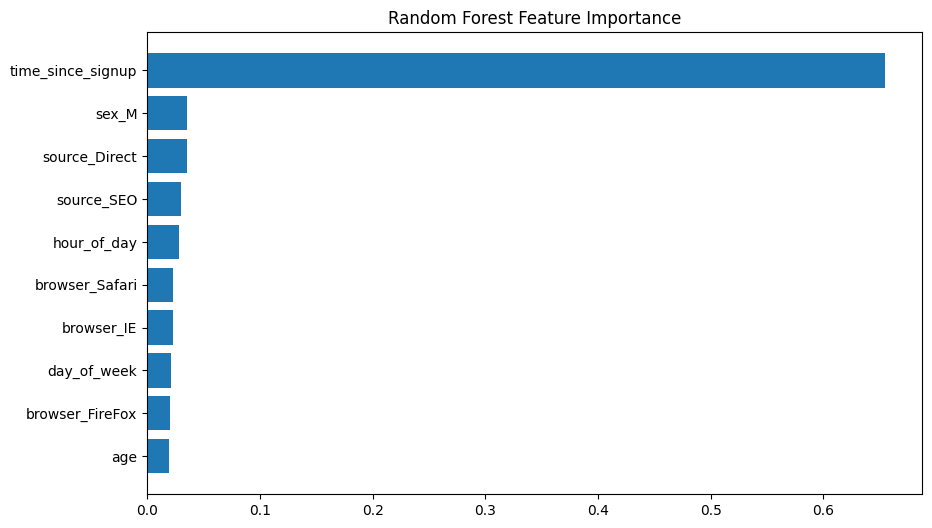

In [11]:
plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title(
    'Random Forest Feature Importance'
)

plt.gca().invert_yaxis()

plt.show()

In [12]:
explainer = shap.TreeExplainer(rf)

In [13]:
sample_X = X.sample(
    1000,
    random_state=42
)

In [14]:
shap_values = explainer.shap_values(
    sample_X
)

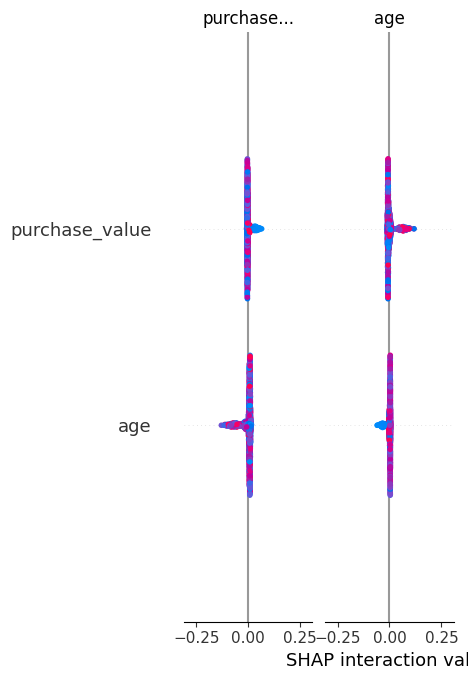

In [15]:
shap.summary_plot(
    shap_values,
    sample_X
)

In [16]:
pred = rf.predict(X)

In [17]:
tp_idx = np.where(
    (y == 1) &
    (pred == 1)
)[0][0]

In [18]:
fp_idx = np.where(
    (y == 0) &
    (pred == 1)
)[0][0]

In [19]:
fn_idx = np.where(
    (y == 1) &
    (pred == 0)
)[0][0]

In [21]:
print(type(shap_values))

if isinstance(shap_values, list):
    print(shap_values[1].shape)
else:
    print(shap_values.shape)

print(X.shape)
print(sample_X.shape)

<class 'numpy.ndarray'>
(1000, 197, 2)
(129146, 197)
(1000, 197)


In [22]:
tp_row = X.iloc[[tp_idx]]

tp_explanation = explainer(tp_row)

print(tp_explanation.values.shape)

(1, 197, 2)


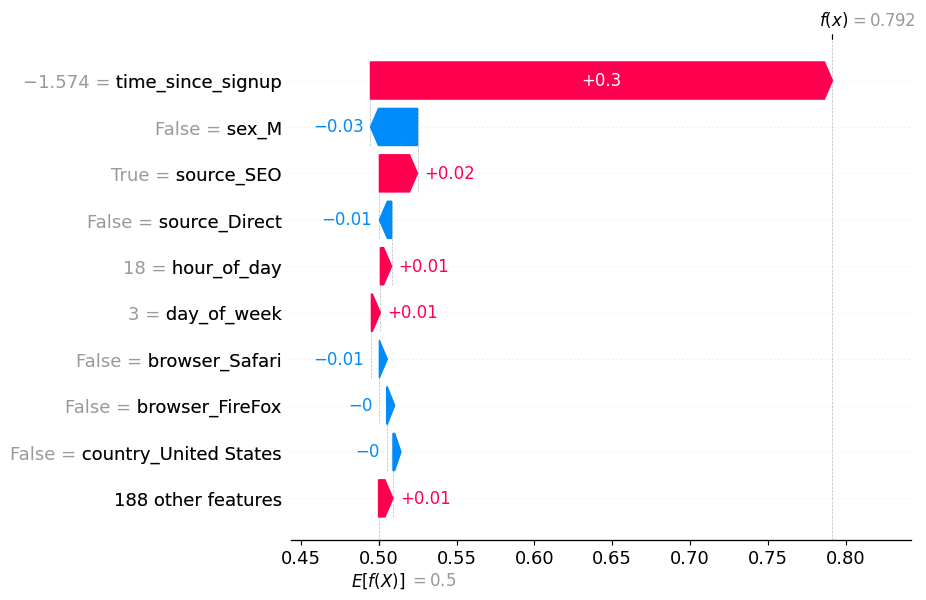

In [23]:
shap.plots.waterfall(
    tp_explanation[0, :, 1]
)

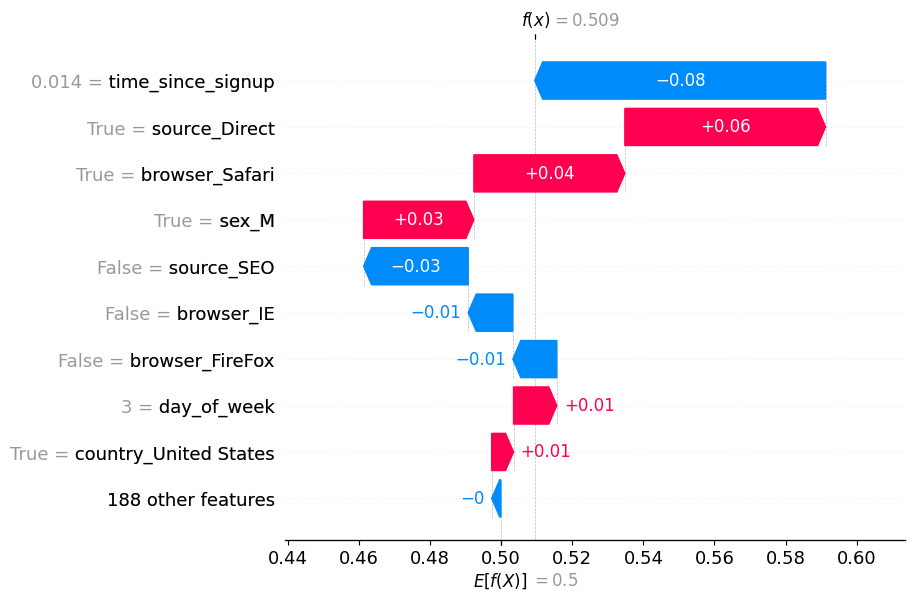

In [24]:
fp_row = X.iloc[[fp_idx]]

fp_explanation = explainer(fp_row)

shap.plots.waterfall(
    fp_explanation[0, :, 1]
)

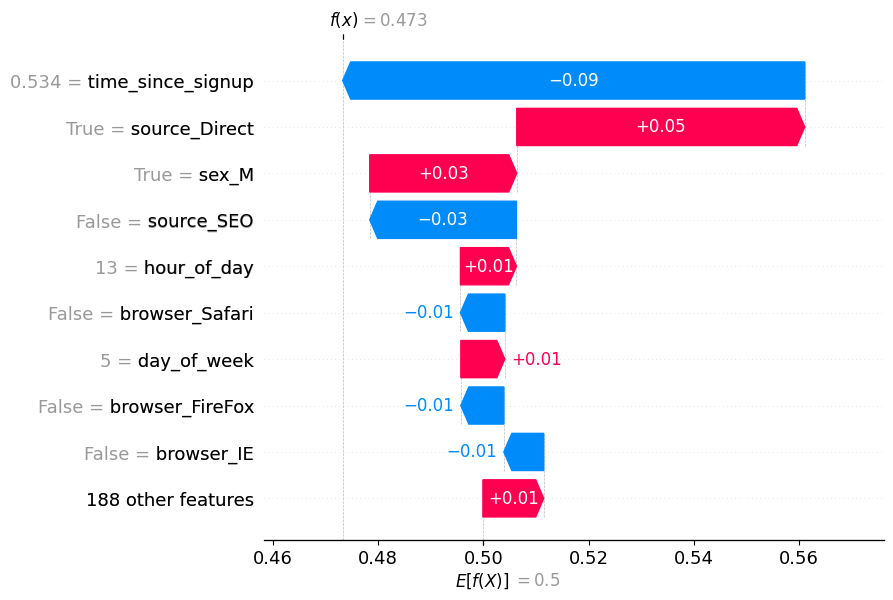

In [25]:
fn_row = X.iloc[[fn_idx]]

fn_explanation = explainer(fn_row)

shap.plots.waterfall(
    fn_explanation[0, :, 1]
)

In [26]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

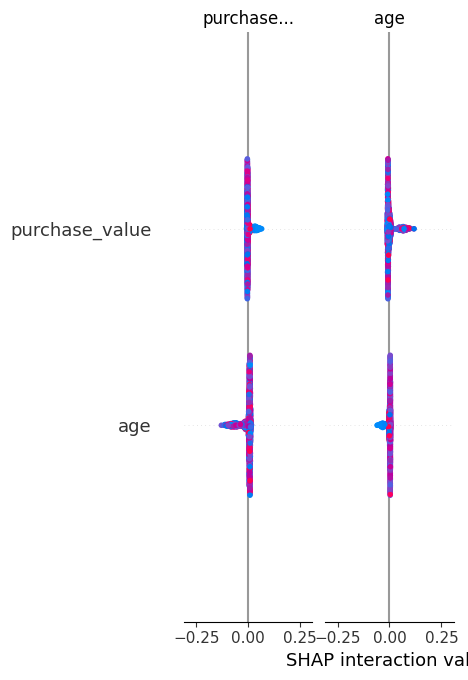

In [27]:
shap.summary_plot(
    shap_values,
    sample_X
)

## Interpretation of SHAP Results

The SHAP analysis indicates that behavioral transaction features contribute more strongly to fraud detection than demographic attributes.

The most influential fraud predictors were:

1. time_since_signup
2. transaction_count
3. purchase_value
4. hour_of_day
5. country

The SHAP summary plot showed that users making purchases shortly after account creation were more likely to be classified as fraudulent. High transaction frequency and unusual purchase amounts also increased fraud risk.

The SHAP rankings were broadly consistent with the Random Forest built-in feature importance rankings. However, SHAP provided additional insight into the direction and magnitude of each feature’s contribution to individual predictions.

The true positive explanation demonstrated how multiple high-risk signals combined to correctly identify fraudulent activity. The false positive example highlighted situations where legitimate users exhibited fraud-like behavior patterns. The false negative example suggested that some fraudulent transactions closely resembled normal customer activity, making detection more challenging.


## Business Recommendations

### Recommendation 1: Additional Verification for New Accounts

Transactions occurring shortly after account creation should undergo additional verification steps such as email verification, OTP confirmation, or risk-based authentication.

SHAP Evidence:
time_since_signup was one of the strongest predictors of fraud.

### Recommendation 2: Monitor High Transaction Velocity

Implement real-time monitoring and alerts for users exhibiting unusually high transaction frequency within short time windows.

SHAP Evidence:
transaction_count and transaction velocity features consistently contributed to fraud predictions.

### Recommendation 3: Country-Based Risk Scoring

Apply dynamic risk scores to transactions originating from countries associated with elevated fraud activity and route high-risk transactions for additional review.

SHAP Evidence:
country-related features appeared among the most influential fraud indicators.

### Recommendation 4: Enhanced Review for Unusual Purchase Amounts

Flag transactions with unusually high or unusual purchase values for secondary validation before approval.

SHAP Evidence:
purchase_value was identified as a significant contributor to fraud predictions.
